In [1]:
import multiprocessing as mp
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, QTable, vstack
from tqdm import tqdm
import astropy.units as u
from astropy.io import fits

import lib
import task
from subscan_class import Subscan
from binner import Binner
from cleaner_class import Cleaner 



In [2]:
cfg = lib.get_config_file("./config.yaml")
tods_dir = cfg['paths']['tods']
tods_names = os.listdir(tods_dir)
tods_files = []
for name in tods_names:
    tods_files.append(os.path.join(tods_dir, name))
sorted(tods_files)
print('Making map of ', tods_dir)
print('Total number of subscan:', len(tods_names))

subscan = Subscan(cfg, mode=cfg['telescope'])
subscan.init_tele()

#Checking if number of feeds changes during the subscans
num_feed = lib.check_number_channel(tods_files)

name_target = cfg['name_target']
data_obs = cfg['date_obs']

bin_mode = cfg['binner']['frame']
projection = cfg['binner']['projection']
binner = Binner(bin_mode=bin_mode, projection=projection)
print('Binner mode = ', bin_mode)
print('Projection = ', projection)

if type(cfg['paths']['skydip']) == str:
    resps = lib.responsivity(cfg, 0, 0, 0)

cleaner = Cleaner(cfg)
cleaner.init_cleaner()


part = task.partial(task.enrich_dataframe)
scan = task.load_data(tods_dir, part)

Making map of  /Users/eleonora/Desktop/mistral/OBS/SRT-dicembre/20241214-204624-MISTRAL-JUPITER_TY-2.5_TZ-7
Total number of subscan: 60
-------------------------------------
         Telescope: SRT  
-------------------------------------
Diameter = 60 m
Band = 90.0-120.0 GHz
Efficiency = 0.3 
Gaussian beam = ????????????? 
Beam area = ???????????? 
-------------------------------------
Binner mode =  AZEL
Projection =  SIN
-----> You choose to not filter the data, are you sure? :)
Loaded 60 files
(315,) 315 [351 350 349 348 347 346 345 344 343 342 341 340 339 338 337 336 335 334
 333 332 331 330 329 328 327 326 325 324 323 322 321 320 319 318 317 316
 315]
(315,) 315 [351 350 349 348 347 346 345 344 343 342 341 340 339 338 337 336 335 334
 333 332 331 330 329 328 327 326 325 324 323 322 321 320 319 318 317 316
 315]
(315,) 315 [351 350 349 348 347 346 345 344 343 342 341 340 339 338 337 336 335 334
 333 332 331 330 329 328 327 326 325 324 323 322 321 320 319 318 317 316
 315]
(315,) 31

In [3]:
#scan

In [4]:
'''r = np.load('./gain.npy')
plt.hist(r)
plt.show()

print(np.median(r))'''

"r = np.load('./gain.npy')\nplt.hist(r)\nplt.show()\n\nprint(np.median(r))"

In [5]:

#scan_all = scan.copy #save a copy of scan with all the subscans

bad_subscans = sorted(list(set(scan['n_subscan'][scan['good/bad']=='bad'])))

for i in range(len(bad_subscans)):
    mask = scan['n_subscan'] != bad_subscans[i]
    scan = scan[mask]
    

In [6]:
'''from scipy.optimize import curve_fit
def lin_func(x, m, q):
    return m*x+q

ch=5
ts = scan[scan['ch']==ch]['tod_raw']
mask = scan[scan['ch']==ch]['mask']
time = range(len(ts[mask]))
parfit, covfit = curve_fit(f=lin_func, xdata=time, ydata=ts[mask])
res = ts - lin_func(range(len(ts)), *parfit)

#ch=scan[scan['ch']==ch]
plt.plot(scan[scan['ch']==ch]['tod_raw'])#-np.mean(scan[scan['ch']==ch]['tod_raw']))
#plt.plot(scan[scan['ch']==ch]['tod_raw']-np.mean(scan[scan['ch']==ch+10]['tod_raw']))
#plt.plot(scan[scan['ch']==ch]['tod_dt'])
#plt.plot(res)
#plt.plot(lin_func(range(len(ts)), *parfit)-np.mean(scan[scan['ch']==ch]['tod_raw']))
plt.show()'''

"from scipy.optimize import curve_fit\ndef lin_func(x, m, q):\n    return m*x+q\n\nch=5\nts = scan[scan['ch']==ch]['tod_raw']\nmask = scan[scan['ch']==ch]['mask']\ntime = range(len(ts[mask]))\nparfit, covfit = curve_fit(f=lin_func, xdata=time, ydata=ts[mask])\nres = ts - lin_func(range(len(ts)), *parfit)\n\n#ch=scan[scan['ch']==ch]\nplt.plot(scan[scan['ch']==ch]['tod_raw'])#-np.mean(scan[scan['ch']==ch]['tod_raw']))\n#plt.plot(scan[scan['ch']==ch]['tod_raw']-np.mean(scan[scan['ch']==ch+10]['tod_raw']))\n#plt.plot(scan[scan['ch']==ch]['tod_dt'])\n#plt.plot(res)\n#plt.plot(lin_func(range(len(ts)), *parfit)-np.mean(scan[scan['ch']==ch]['tod_raw']))\nplt.show()"

In [7]:
'''#plt.plot(scan[scan['ch']==ch]['az'], scan[scan['ch']==ch]['el'])
#plt.show()

plt.plot(scan[scan['ch']==ch]['lon'], scan[scan['ch']==ch]['lat'])
plt.show()'''

"#plt.plot(scan[scan['ch']==ch]['az'], scan[scan['ch']==ch]['el'])\n#plt.show()\n\nplt.plot(scan[scan['ch']==ch]['lon'], scan[scan['ch']==ch]['lat'])\nplt.show()"

In [8]:
'''npixels = 128
pixel_size=cfg['pixel_size'] #30 per luna
hdul = fits.open(tods_files[0])
ra_center = hdul['PRIMARY'].header['HIERARCH RightAscension']
dec_center = hdul['PRIMARY'].header['HIERARCH Declination']


scan0= scan[scan['ch']==0]

radius = np.deg2rad(cfg['filtering']['radius']/3600)

mask_ra_maj = scan0['lon'] > ra_center-radius
ra_mask = scan0[mask_ra_maj]
mask_ra_min = ra_mask['lon'] < ra_center+radius 
ra_mask = ra_mask[mask_ra_min]

dist_from_center = np.sqrt((scan0['lon'] - ra_center)**2 + (scan0['lat']-dec_center)**2)
mask = dist_from_center <= radius
ra_mask = scan0[~mask]
for i in range(len(scan0)):
    if mask[i] is True:
        scan0['tod_raw'] = np.nan
plt.plot(ra_mask['tod_raw'])
#plt.plot(scan0['tod_raw'])
plt.plot(~mask)
plt.show()

data_filt_map_ch, count_map, scan_wcs = binner.bin_map(lon=ra_mask['lon'], lat=ra_mask['lat'], 
                                        tods=ra_mask['tod_raw'],
                                        center_ra=ra_center, center_dec=dec_center,
                                        npix_x=npixels, npix_y=npixels, pixel_size_deg=pixel_size/3600)

data_filt_map_ch[np.isnan(data_filt_map_ch)] = 0
data_filt_map_ch = data_filt_map_ch[20:-20,20:-20]
lib.plot_map(data_filt_map_ch, cfg=cfg, wcs=scan_wcs)

import scipy.ndimage as ndimage

img_smooth = ndimage.gaussian_filter(data_filt_map_ch, sigma=16, order=0)
lib.plot_map(data_filt_map_ch-img_smooth, cfg=cfg, wcs=scan_wcs)

img_smooth = ndimage.gaussian_filter(data_filt_map_ch, sigma=24, order=0)
lib.plot_map(data_filt_map_ch-img_smooth, cfg=cfg, wcs=scan_wcs)

img_smooth = ndimage.gaussian_filter(data_filt_map_ch, sigma=32, order=0)
lib.plot_map(data_filt_map_ch-img_smooth, cfg=cfg, wcs=scan_wcs)

ts = []
for ch in range(num_feed):
    ts.append(ra_mask['tod_dt'])


'''

"npixels = 128\npixel_size=cfg['pixel_size'] #30 per luna\nhdul = fits.open(tods_files[0])\nra_center = hdul['PRIMARY'].header['HIERARCH RightAscension']\ndec_center = hdul['PRIMARY'].header['HIERARCH Declination']\n\n\nscan0= scan[scan['ch']==0]\n\nradius = np.deg2rad(cfg['filtering']['radius']/3600)\n\nmask_ra_maj = scan0['lon'] > ra_center-radius\nra_mask = scan0[mask_ra_maj]\nmask_ra_min = ra_mask['lon'] < ra_center+radius \nra_mask = ra_mask[mask_ra_min]\n\ndist_from_center = np.sqrt((scan0['lon'] - ra_center)**2 + (scan0['lat']-dec_center)**2)\nmask = dist_from_center <= radius\nra_mask = scan0[~mask]\nfor i in range(len(scan0)):\n    if mask[i] is True:\n        scan0['tod_raw'] = np.nan\nplt.plot(ra_mask['tod_raw'])\n#plt.plot(scan0['tod_raw'])\nplt.plot(~mask)\nplt.show()\n\ndata_filt_map_ch, count_map, scan_wcs = binner.bin_map(lon=ra_mask['lon'], lat=ra_mask['lat'], \n                                        tods=ra_mask['tod_raw'],\n                                        ce

In [12]:
pixel_size=cfg['pixel_size']
if cfg['name_target']=='MOON':
    pixel_size = 30

if cfg['num_ch_map']=='all':
    n_ch = np.copy(num_feed)
elif cfg['num_ch_map']<num_feed:
    n_ch = cfg['num_ch_map']
else:
    raise ValueError('Choose an adequate number of channel with which build the map.')

hdul = fits.open(tods_files[0])
ra_center = hdul['PRIMARY'].header['HIERARCH RightAscension']
dec_center = hdul['PRIMARY'].header['HIERARCH Declination']

npixels = 256
center_map = (int(npixels/2), int(npixels/2))
mappe_filt = []
mappe_unfilt = []
counts = []
for ch in tqdm(range(n_ch)): #n_ch
    try:
        data_filt_map, count_map, scan_wcs = binner.bin_map(lon=scan['lon'][scan['ch']==ch], lat=scan['lat'][scan['ch']==ch], 
                                        tods=scan['tod_filt'][scan['ch']==ch],
                                        center_ra=ra_center, center_dec=dec_center,
                                        npix_x=npixels, npix_y=npixels, pixel_size_deg=pixel_size/3600)
        if cfg['unfilt_map']=='raw':
            data_unfilt_map, count_map1, scan_wcs = binner.bin_map(lon=scan['lon'][scan['ch']==ch], lat=scan['lat'][scan['ch']==ch], 
                                        tods=scan['tod_raw'][scan['ch']==ch],
                                        center_ra=ra_center, center_dec=dec_center,
                                        npix_x=npixels, npix_y=npixels, pixel_size_deg=pixel_size/3600)
        
        if cfg['unfilt_map']=='dt':
            data_unfilt_map, count_map1, scan_wcs = binner.bin_map(lon=scan['lon'][scan['ch']==ch], lat=scan['lat'][scan['ch']==ch], 
                                        tods=scan['tod_dt'][scan['ch']==ch],
                                        center_ra=ra_center, center_dec=dec_center,
                                        npix_x=npixels, npix_y=npixels, pixel_size_deg=pixel_size/3600)

        mappe_filt.append(data_filt_map)
        mappe_unfilt.append(data_unfilt_map)
        counts.append(count_map)
    except:
        print(ch)


  0%|          | 0/352 [00:00<?, ?it/s]

100%|██████████| 352/352 [00:30<00:00, 11.72it/s]


In [13]:
#np.shape(mappe_unfilt)

RMS =  0.008154170414561792


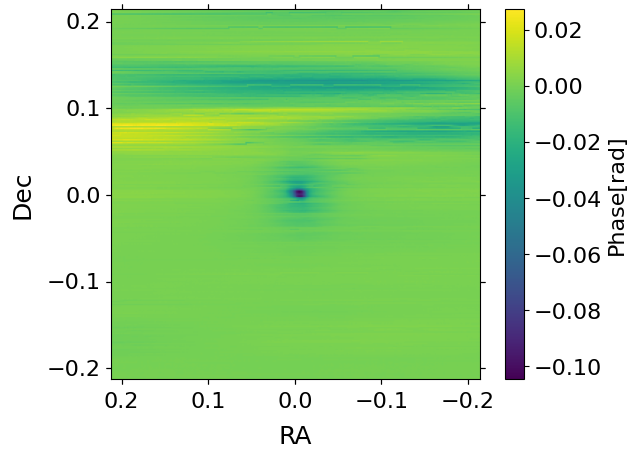

In [14]:
filt_map = np.flip(np.nanmean(np.dstack(mappe_filt),2),axis=1)
unfilt_map = np.flip(np.nanmean(np.dstack(mappe_unfilt),2),axis=1)
counts_map = np.flip(np.nansum(np.dstack(counts),2),axis=1)
std_map = np.flip(np.nanstd(np.dstack(mappe_filt),2),axis=1)

from photutils.aperture import CircularAperture, ApertureStats
r_beam = 6/cfg['pixel_size']
beam_pos = (npixels/5,npixels/5)
beam_ap = CircularAperture(beam_pos, r_beam)
beam = [beam_ap, beam_pos]
halo =  CircularAperture(center_map, 2*60/cfg['pixel_size'])

rms_aper =  CircularAperture(center_map, 5*60/cfg['pixel_size'])
aperstats_rms = ApertureStats(filt_map, rms_aper)   
rms = aperstats_rms.std
print('RMS = ', rms)

if cfg['plot_maps']['plot_filt']==True: 
        lib.plot_map(filt_map, cfg=cfg, wcs=scan_wcs) #[170:320,170:320]
        
if cfg['plot_maps']['plot_unfilt']==False:
        lib.plot_map(unfilt_map, cfg=cfg,wcs=scan_wcs, beam=beam)

if cfg['plot_maps']['plot_counts']==True:
        lib.plot_map(counts_map, cfg=cfg,wcs=scan_wcs, beam=beam)

if cfg['plot_maps']['plot_std']==True:
        lib.plot_map(std_map, cfg=cfg,wcs=scan_wcs, beam=beam)

In [12]:
#SAVING MAP as file fits
mean_EL = np.rad2deg(np.nanmean(scan['el']))
print('Mean EL = ', mean_EL)

if '_RA' in cfg['paths']['tods']:
    scan_type = 'RA'
elif '_DEC' in cfg['paths']['tods']:
    scan_type = 'DEC'
elif '_AZ' in cfg['paths']['tods']:
    scan_type = 'AZ'
elif '_EL' in cfg['paths']['tods']:
    scan_type = 'EL'
else:
    scan_type = 'unknownscantype'

hour = cfg['paths']['tods'].split('/')[-1].split(str(cfg['date_obs']))[-1].split('-')[1]
dir_gen = cfg['paths']['tods'].split(cfg['date_obs'])[0]
path_map = cfg['paths']['tods'] + '_maps_' + str(cfg['pixel_size']) + 'arcsec/'
#path_map = dir_gen + '/' + cfg['name_target'] + scan_type + '_maps_' + str(cfg['pixel_size']) + 'arcsec/'# + '_calSKYDIP_'
#path_map = '/Users/eleonora/Desktop/SRT-febbraio/' + cfg['name_target'] + scan_type + '_maps_' + str(cfg['pixel_size']) + 'arcsec/'
#path_map = '/Users/eleonora/Desktop/SRT-aprile/' + cfg['name_target'] + '_'+ scan_type +'_maps_' + str(cfg['pixel_size']) + '/' #+ 'arcsec_pol4deg_custCM_confrontofiltro/'

if cfg['save_map']==True:
    if os.path.isdir(path_map)==False:
        os.mkdir(path_map)
    print('Map save in folder:', path_map)

    fits_name = cfg['date_obs'] + '-' + hour + '_' + name_target + f'_map' + scan_type
    if type(cfg['paths']['skydip']) == str:
        fits_name += '_calSKYDIP'
    myfile = path_map + fits_name + '.fits'
    print('Name file: ', fits_name)
    if os.path.isfile(myfile):
        os.remove(myfile)
    hdu_list = []
    cards_list = []
    #cards_list.append(fits.Card('HIERARCH Channel name', 'chp_'+ str(i).zfill(3)))
    cards_list.append(fits.Card('TARGET', name_target))
    #cards_list.append(fits.Card('HIERARCH RA center scan', subscan.ra_center, 'Source RA at J2000 (radians)'))
    #cards_list.append(fits.Card('HIERARCH dec center scan', subscan.dec_center, 'Source dec at J2000 (radians'))
    cards_list.append(fits.Card('HIERARCH Date', cfg['date_obs']))
    cards_list.append(fits.Card('HIERARCH Mean Elevation', mean_EL, '(deg)'))
    if cfg['paths']['skydip'] == False:
        cards_list.append(fits.Card('HIERARCH Skydip calibration', 'No'))
    elif type(cfg['paths']['skydip']) == str:
        cards_list.append(fits.Card('HIERARCH Skydip calibration', 'Yes'))
        cards_list.append(fits.Card('HIERARCH Path skydip', cfg['paths']['skydip'].split('/')[-1]))
        cards_list.append(fits.Card('HIERARCH tau', cfg['paths']['tau']))
        cards_list.append(fits.Card('HIERARCH T atm', cfg['paths']['T_atm']))
    header_wcs = scan_wcs.to_header()
    
    hdr = fits.Header(cards=cards_list)
    prim_hdu0 = fits.PrimaryHDU(header=hdr)
    prim_hdu1 = fits.ImageHDU(header=header_wcs, data=filt_map, name='FILT MAP')
    prim_hdu2 = fits.ImageHDU(header=header_wcs, data=counts_map, name='COUNTS MAP')
    prim_hdu3 = fits.ImageHDU(header=header_wcs, data=unfilt_map, name='UNFILT MAP')
    prim_hdu4 = fits.ImageHDU(header=header_wcs, data=std_map, name='STD MAP')
    fits_hdu_list = fits.HDUList([prim_hdu0, prim_hdu1, prim_hdu2, prim_hdu3, prim_hdu4])
    
    fits_hdu_list.writeto(myfile, overwrite=True)

#SAVING single pixel maps as a fits file
if cfg['save_single_pixel_maps']==True: 
    path_single_map = path_map + 'single_pixel_maps/'
    if os.path.isdir(path_single_map)==False:
        os.mkdir(path_single_map)
    print('Single pixel maps save in folder:', path_single_map)

    for i in range(len(mappe_filt)):#len(maps_all)
        fits_name = name_target + '_chp_'+ str(i).zfill(3)
        myfile = path_single_map + fits_name + '.fits'
        if os.path.isfile(myfile):
            os.remove(myfile)
        hdu_list = []
        cards_list = []
        cards_list.append(fits.Card('HIERARCH Channel name', 'chp_'+ str(i).zfill(3)))
        cards_list.append(fits.Card('TARGET', name_target))
        #cards_list.append(fits.Card('HIERARCH RA center scan', subscan.ra_center, 'Source RA at J2000 (radians)'))
        #cards_list.append(fits.Card('HIERARCH dec center scan', subscan.dec_center, 'Source dec at J2000 (radians'))
        cards_list.append(fits.Card('HIERARCH Date', cfg['date_obs']))
        cards_list.append(fits.Card('HIERARCH  Mean Elevation', mean_EL, '(deg)'))
        if cfg['paths']['skydip'] == False:
            cards_list.append(fits.Card('HIERARCH Skydip calibration', 'No'))
        elif type(cfg['paths']['skydip']) == str:
            cards_list.append(fits.Card('HIERARCH Skydip calibration', 'Yes'))
            cards_list.append(fits.Card('HIERARCH Path skydip', cfg['paths']['skydip']))
            cards_list.append(fits.Card('HIERARCH tau', cfg['paths']['tau']))
            cards_list.append(fits.Card('HIERARCH T atm', cfg['paths']['T_atm']))

        hdr = fits.Header(cards=cards_list)
        prim_hdu0 = fits.PrimaryHDU(header=hdr)
        header_wcs = scan_wcs.to_header()
        prim_hdu1 = fits.ImageHDU(header=header_wcs, data=mappe_filt[i], name='FILT MAP')
        prim_hdu2 = fits.ImageHDU(header=header_wcs, data=counts[i], name='COUNTS MAP')
        prim_hdu3 = fits.ImageHDU(header=header_wcs, data=mappe_unfilt[i], name='UNFILT MAP')
        fits_hdu_list = fits.HDUList([prim_hdu0, prim_hdu1, prim_hdu2, prim_hdu3])

        fits_hdu_list.writeto(myfile, overwrite=True)

Mean EL =  61.91998148511488


In [13]:
# SALVARE IMMAGINE IN FITS AL VOLO
'''
path_map = cfg['paths']['tods'] + '_maps_' + str(cfg['pixel_size']) + 'arcsec_try/'

if cfg['save_map']==True:
    if os.path.isdir(path_map)==False:
        os.mkdir(path_map)
    print('Map save in folder:', path_map)
    fits_name = cfg['date_obs'] + '-' + hour + '_' + name_target + f'_map' + scan_type
    myfile = path_map + fits_name + '.fits'
    print('Name file: ', fits_name)
    if os.path.isfile(myfile):
        os.remove(myfile)

    header_wcs = scan_wcs.to_header()
    prim_hdu1 = fits.ImageHDU(header=header_wcs, data=filt_map, name='IMG')
    prim_hdu1.writeto(myfile, overwrite=True)
'''

"\npath_map = cfg['paths']['tods'] + '_maps_' + str(cfg['pixel_size']) + 'arcsec_try/'\n\nif cfg['save_map']==True:\n    if os.path.isdir(path_map)==False:\n        os.mkdir(path_map)\n    print('Map save in folder:', path_map)\n    fits_name = cfg['date_obs'] + '-' + hour + '_' + name_target + f'_map' + scan_type\n    myfile = path_map + fits_name + '.fits'\n    print('Name file: ', fits_name)\n    if os.path.isfile(myfile):\n        os.remove(myfile)\n\n    header_wcs = scan_wcs.to_header()\n    prim_hdu1 = fits.ImageHDU(header=header_wcs, data=filt_map, name='IMG')\n    prim_hdu1.writeto(myfile, overwrite=True)\n"

In [14]:
import pywt

titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']

coeffs2 = pywt.dwt2(filt_map, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap='viridis', origin='lower')
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()
    
coeffsDEC = pywt.dwt2(filt_map, 'bior1.3')
LL_dec, (LH_dec, HL_dec, HH_dec) = coeffsDEC


ModuleNotFoundError: No module named 'pywt'

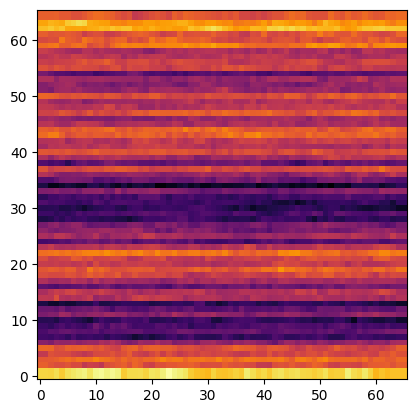

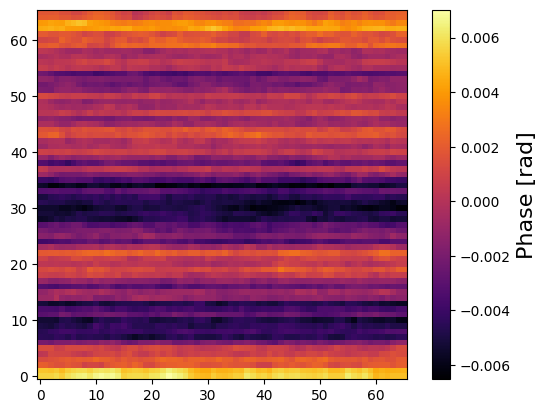

In [ ]:
plt.imshow(LL, origin='lower', cmap='inferno')
plt.show()

import scipy.ndimage as ndimage
img = ndimage.gaussian_filter(LL, sigma=0.5, order=0)
im = plt.imshow(img, interpolation='nearest', origin='lower', cmap='inferno')
cbar = plt.colorbar(im)
if type(cfg['paths']['skydip'])==str:
        cbar_label='Kelvin [K]'
else:
        cbar_label='Phase [rad]'
cbar.set_label(label=cbar_label, size=16)
plt.show()

In [ ]:
6/4

1.5

In [ ]:
from astropy.coordinates import SkyCoord

rho = SkyCoord(353.05,16.90, frame='galactic', unit='deg')
rho.icrs.to_string('hmsdms')


'16h26m24.85039052s -24d25m22.0233164s'